In [1]:
!pip install yfinance tensorflow scikit-learn pandas numpy matplotlib

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.0 MB 2.4 MB/s eta 0:00:01
   -------------------------- ------------- 1.3/2.0 MB 2.3 MB/s eta 0:00:01
   ------------------------------------- -- 1.8/2.0 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 2.3 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/4.0 MB 3.4 MB/s eta 0:00:02
   ------------- -------------------------- 1.3/4.0 MB 3.4 MB/s eta 0:00:01
   ------------------ --------------------- 1.8/4.0 MB 3.4 MB/s eta 0:00:01
   ----------------------- ---------------- 2.4/4.0 MB 3.0 MB/s eta 0:00:01
   ---------------------------- ----------- 2.9/4.0 MB 3.2 MB/s eta 0:00:01
   ------------------------------------ --- 3.7/4.0 MB 3.0 MB/s eta 0:00:01
   ---------------------------------

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [3]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [4]:
data = yf.download("AAPL", start="2015-01-01", end="2026-01-01", auto_adjust=False)
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2015-01-02,24.171753,27.332500,27.860001,26.837500,27.847500,212818400
2015-01-05,23.490797,26.562500,27.162500,26.352501,27.072500,257142000
2015-01-06,23.493013,26.565001,26.857500,26.157499,26.635000,263188400
2015-01-07,23.822432,26.937500,27.049999,26.674999,26.799999,160423600
2015-01-08,24.737749,27.972500,28.037500,27.174999,27.307501,237458000


In [5]:
df = data[['Close']].copy()
df.dropna(inplace=True)
df.head()

Price,Close
Ticker,AAPL
Date,
2015-01-02,27.332500
2015-01-05,26.562500
2015-01-06,26.565001
2015-01-07,26.937500
2015-01-08,27.972500


In [6]:
print("Dataset Shape:", df.shape)
print(df.tail())

Dataset Shape: (2766, 1)
Price            Close
Ticker            AAPL
Date                  
2025-12-24  273.809998
2025-12-26  273.399994
2025-12-29  273.760010
2025-12-30  273.079987
2025-12-31  271.859985


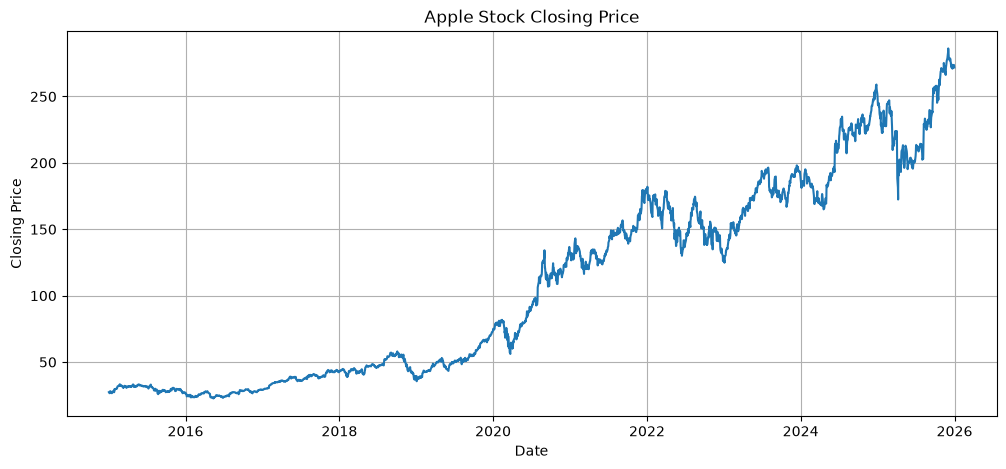

In [7]:
plt.figure(figsize=(12,5))
plt.plot(df['Close'])
plt.title('Apple Stock Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()

In [8]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df[['Close']])
print(scaled_data[:5])

[[0.01800991]
 [0.01508887]
 [0.01509835]
 [0.01651145]
 [0.02043778]]


In [9]:
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], 1)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (2706, 60, 1)
y Shape: (2706,)


In [10]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2164
Testing samples: 542


In [11]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

c:\Users\ASUS\anaconda3\envs\dl\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0077 - val_loss: 5.3831e-04
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 7.7648e-04 - val_loss: 5.4372e-04
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.6026e-04 - val_loss: 5.8015e-04
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 6.4752e-04 - val_loss: 0.0014
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 6.5254e-04 - val_loss: 9.4384e-04
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 5.5259e-04 - val_loss: 5.0986e-04
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 5.6184e-04 - val_loss: 0.0015
Epoch 8/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 5.3371e-04 - val_loss: 0.0023
Epoch 9/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 4.9881e-04 - val_loss: 6.0370e-04
Epoch 10/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 4.7715e-04 - val_loss: 4.0871e-04
Epoch 11/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 4.0784e-04 - val_loss: 6.

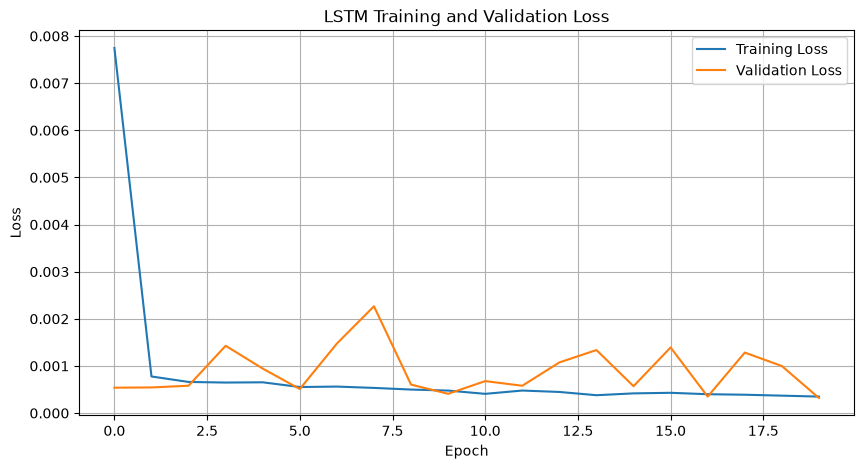

In [13]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y_test.reshape(-1,1))

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [15]:
mae = mean_absolute_error(actual_prices, predictions)
rmse = np.sqrt(mean_squared_error(actual_prices, predictions))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 9.878537308246008
Root Mean Squared Error (RMSE): 11.964249855249113


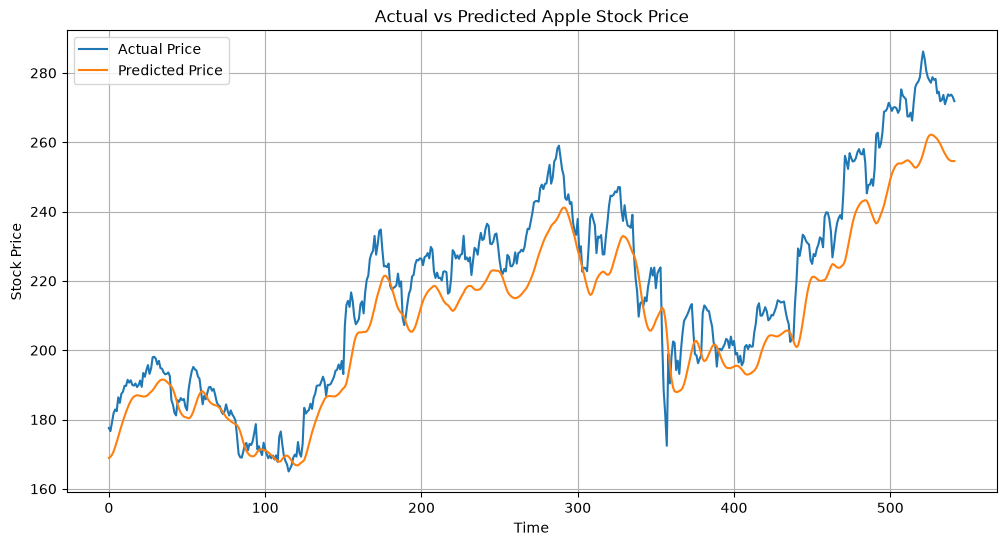

In [16]:
plt.figure(figsize=(12,6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.title('Actual vs Predicted Apple Stock Price')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
last_60_days = scaled_data[-60:]
X_future = last_60_days.reshape(1, 60, 1)

next_day_scaled = model.predict(X_future)
next_day_price = scaler.inverse_transform(next_day_scaled)

print("Predicted Next Day Closing Price:", float(next_day_price[0][0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Next Day Closing Price: 254.564697265625
